In [1]:
#!pip install segmentation-models-pytorch
#!pip install -U git+https://github.com/albumentations-team/albumentations
#!pip install --upgrade opencv-contrib-python

In [2]:
!nvidia-smi

Tue Jun 11 10:09:50 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.171.04             Driver Version: 535.171.04   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090        Off | 00000000:01:00.0 Off |                  N/A |
| 34%   53C    P8              23W / 370W |   1250MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Dataset

In [3]:
#!git clone https://github.com/parth1620/Human-Segmentation-Dataset-master.git

In [4]:
#import sys
#sys.path.append('Human-Segmentation-Dataset-master')

In [5]:
import torch 
import cv2

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

## Task : 2 Setup Configurations


In [6]:
#CSV_FILE = 'DataFN.csv'
#CSV_testFILE = 'DataTestFN.csv'
#CSV_FILE = 'DataFN_3Ch_FT1T2.csv'
#CSV_testFILE = 'DatatestFN_3Ch_FT1T2.csv'
#CSV_FILE = 'DataFN_3Ch_Flair5avg.csv'
#CSV_testFILE = 'DatatestFN_3Ch_Flair5avg.csv'
CSV_FILE = 'Data2FN_3Ch_Flair.csv'
CSV_testFILE = 'Datatest2FN_3Ch_Flair.csv'

#CSV_FILE = 'DataFN_mat5ch_Flair.csv'
#CSV_testFILE = 'DatatestFN_mat5ch_Flair.csv'

CSV_testFILE0 = 'DataTestFN0.csv'
CSV_testFILE100 = 'DataTestFN100.csv'
DATA_DIR = ''

DEVICE = 'cuda'

EPOCHS = 500
IMAGE_SIZE = 256
BATCH_SIZE = 64
Patience = 30
ENCODER = 'timm-efficientnet-b0'
WEIGHTS = 'imagenet'

In [7]:
df = pd.read_csv(CSV_FILE)
test_df = pd.read_csv(CSV_testFILE)
test_df0 = pd.read_csv(CSV_testFILE0)
test_df100 = pd.read_csv(CSV_testFILE100)
df.head()

,images,masks
0,Dataset/train/Ch3_Flair2/P1_T1_32.png,Dataset/train/Mask/P1_T1_32.png
1,Dataset/train/Ch3_Flair2/P1_T1_33.png,Dataset/train/Mask/P1_T1_33.png
2,Dataset/train/Ch3_Flair2/P1_T1_34.png,Dataset/train/Mask/P1_T1_34.png
3,Dataset/train/Ch3_Flair2/P1_T1_35.png,Dataset/train/Mask/P1_T1_35.png
4,Dataset/train/Ch3_Flair2/P1_T1_36.png,Dataset/train/Mask/P1_T1_36.png


In [8]:
from scipy.io import loadmat

row = df.iloc[500]

image_path = row.images
mask_path = row.masks


# Load the .mat file
#mat = loadmat(image_path)
# The result is a dictionary where keys are the variable names, and the values are the stored variables
#matrix = mat['im']
#images = matrix[:,:,1:4]
image = cv2.imread(image_path)
#image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

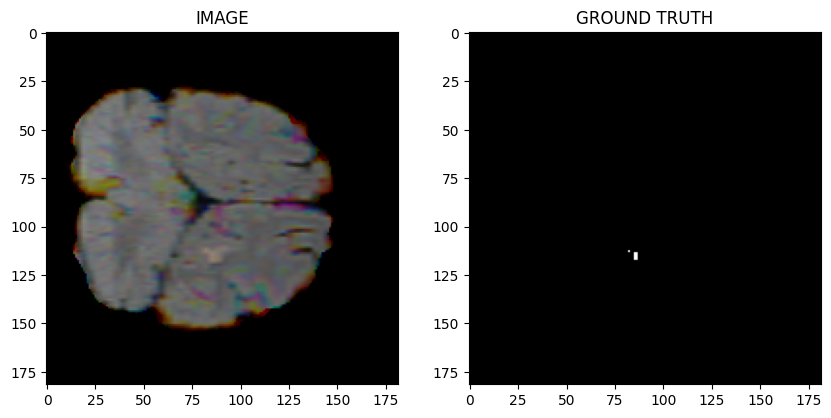

In [9]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
        
ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')

In [10]:
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)

## Task 3 : Augmentation Functions


In [11]:
import albumentations as A

def get_train_augs():
   return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        #A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.0, rotate_limit=0, p=0.5),
        #A.RandomBrightnessContrast(p=0.5),
        #A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
   ])
def get_valid_augs():
   return A.Compose([
   ])

## Task 4 : Create Custom Dataset


In [12]:
from torch.utils.data import Dataset

class SegmentationDataset(Dataset):
  def __init__(self,df, augmentations):
    self.df=df
    self.augmentations = augmentations 
  def __len__(self):
    return len(self.df)
  def __getitem__(self ,idx):
    row = self.df.iloc[idx]
    image_path = row.images
    mask_path = row.masks

    #print('image path: ', image_path)
    #print('mask path: ', mask_path)
    image = cv2.imread(image_path)
    # Load the .mat file
    #mat = loadmat(image_path)
    # The result is a dictionary where keys are the variable names, and the values are the stored variables
    #matrix = mat['im']
    ##image1 = matrix[:,:,0:3]
    #image2 = matrix[:,:,2:5]

      
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)

    mask = cv2.imread(mask_path , cv2.IMREAD_GRAYSCALE) #(h,w,c)
    #print('mask 0 size: ', mask.shape)
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    mask =np.expand_dims(mask ,axis=-1)
    #print('image size: ', image.shape)
    #print('mask size: ', mask.shape)

    if self.augmentations :
      data =self.augmentations(image = image , mask = mask)
      image = data['image']
      mask = data ['mask']

    #(h,w,c) -> (c,h,w)
    image = np.transpose(image ,(2,0,1)).astype(np.float32)
    mask = np.transpose(mask ,(2,0,1)).astype(np.float32)

    image = torch.Tensor(image)/255.0
    mask = torch.round(torch.Tensor(mask)/255.0)

    return image,mask

In [13]:
trainset = SegmentationDataset(train_df,get_train_augs())
validset = SegmentationDataset(valid_df,get_valid_augs())
testset = SegmentationDataset(test_df,get_valid_augs())
testset0 = SegmentationDataset(test_df0,get_valid_augs())
testset100 = SegmentationDataset(test_df100,get_valid_augs())


In [14]:
print(f"Size of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")

Size of Trainset : 8432
Size of Validset : 2108


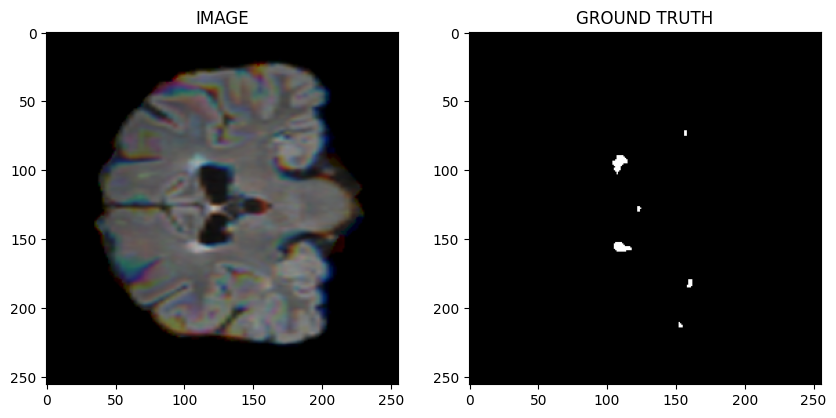

In [15]:
idx = 70
image,mask = trainset[idx]
helper.show_image(image,mask)


## Task 5 : Load dataset into batches


In [16]:
from torch.utils.data import DataLoader

trainloader = DataLoader(trainset , batch_size =BATCH_SIZE , shuffle =True )
validloader = DataLoader(validset , batch_size =BATCH_SIZE  )

In [17]:
print(f"total no,of batches in trainloader: {len(trainloader)}")
print(f"total no,of batches in validloader: {len(validloader)}")

total no,of batches in trainloader: 132
total no,of batches in validloader: 33


In [18]:
for image , mask in trainloader:
  break
print (f'One batch image shape: {image.shape}')
print (f'One batch image shape: {mask.shape}')

One batch image shape: torch.Size([64, 3, 256, 256])
One batch image shape: torch.Size([64, 1, 256, 256])



## Task 6 : Create Segmentation Model


In [19]:
#! pip install segmentation_models_pytorch

In [20]:
from torch import nn 
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

In [21]:

class BinaryIntersection(torch.nn.Module):
    def forward(self, pred, target):
        intersection = (pred * target).sum()
        return  intersection

class BinaryUnion(torch.nn.Module):
    def forward(self, pred, target):
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum() - intersection
        return  union
        
class BinarySum(torch.nn.Module):
    def forward(self, pred, target):
        sumAB = pred.sum() + target.sum()
        return  sumAB
        

A , B = 1 , 1
class BinaryJaccardLoss(torch.nn.Module):
    def forward(self, pred, target):
       if (pred.sum() ==0) and (target.sum() == 0):
            jaccard_index = 1
       else:        
            intersection = (pred * target).sum() + A
            union = pred.sum() + target.sum() - intersection + B
            jaccard_index = 1 - intersection / (union)
       return  jaccard_index


In [22]:
class SegmentationModel (nn.Module):

  def __init__(self):
    super (SegmentationModel , self).__init__()
    
    self.arc = smp.Unet(
        encoder_name= ENCODER ,
        encoder_weights=  WEIGHTS ,
        in_channels= 3 ,
        classes=  1 ,
        activation = None
    )

  def forward (self ,images ,masks = None):
    result = self.arc(images)
    result = torch.sigmoid (result)
      
    if masks != None :
      #print(f'max of result = {result.max()}  , max of mask = {masks.max()}')
      #loss1 = DiceLoss(mode='binary')(result , masks)
      #loss1 = nn.BCEWithLogitsLoss()(result , masks)
      #loss1 = nn.CrossEntropyLoss()(result , masks)
      loss1 = BinaryJaccardLoss()(result , masks)
      #print('loss: ', loss1)
      return result , loss1
    return result

In [23]:
model = SegmentationModel()
model.to(DEVICE)

SegmentationModel(
  (arc): Unet(
    (encoder): EfficientNetEncoder(
      (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Swish()
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (bn1): BatchNormAct2d(
              32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Swish()
            )
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (act1): Swish()
              (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (gate): Sigmoid()
            )
           

In [24]:
from torchsummary import summary
summary(model, (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             864
          Identity-2         [-1, 32, 128, 128]               0
             Swish-3         [-1, 32, 128, 128]               0
    BatchNormAct2d-4         [-1, 32, 128, 128]              64
            Conv2d-5         [-1, 32, 128, 128]             288
          Identity-6         [-1, 32, 128, 128]               0
             Swish-7         [-1, 32, 128, 128]               0
    BatchNormAct2d-8         [-1, 32, 128, 128]              64
            Conv2d-9              [-1, 8, 1, 1]             264
            Swish-10              [-1, 8, 1, 1]               0
           Conv2d-11             [-1, 32, 1, 1]             288
          Sigmoid-12             [-1, 32, 1, 1]               0
    SqueezeExcite-13         [-1, 32, 128, 128]               0
           Conv2d-14         [-1, 16, 1


## Task 7 : Create Train and Validation Function


In [25]:
def train_fn (data_loader , model , optimizer):
  model.train()
  total_loss =0.0

  for images, masks in tqdm(data_loader) :

    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()
    logits , loss = model(images ,masks)
    loss.backward()
    optimizer.step()

    total_loss +=loss.item()

    return total_loss / len(data_loader)

In [26]:
def eval_fn (data_loader , model ):

  model.eval()
  total_loss =0.0

  with torch.no_grad():
    for images, masks in tqdm(data_loader) :

      images = images.to(DEVICE)
      masks = masks.to(DEVICE)

      logits , loss = model(images ,masks)

      total_loss +=loss.item()

  return total_loss / len(data_loader)


## Task 8 : Train Model


In [27]:
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        #torch.save(model.state_dict(), 'checkpoint.pt')
        self.val_loss_min = val_loss

early_stopping = EarlyStopping(patience=Patience, verbose=True)


In [28]:
import GPUtil
GPUtil.showUtilization()


| ID | GPU | MEM |
------------------
|  0 |  1% |  8% |


In [29]:
import GPUtil
from torch.optim.lr_scheduler import ReduceLROnPlateau

LR = 0.01
LR_Reduce_freq = 20

optimizer = torch.optim.Adam(model.parameters(),lr= LR)
#scheduler = ReduceLROnPlateau(optimizer, 'min')
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.8)


best_valid_loss = np.Inf
for i in range(EPOCHS):
    GPUtil.showUtilization()
    print('Learning rate = ', scheduler.get_last_lr()[0])
    train_loss = train_fn(trainloader , model , optimizer)
    #print('train_loss = ', train_loss)
    #valid_loss = eval_fn(validloader , model  )
    valid_loss = 2
    #print('valid_loss = ', valid_loss)

    if valid_loss< best_valid_loss :
        torch.save(model.state_dict(), 'bestModel.pt')
        print ("SAVED")
        best_valid_loss = valid_loss
    print(f"Epoch : {i+1} train_loss :{train_loss} valid_loss :{valid_loss}" )
    
    if (i+1) % LR_Reduce_freq == 0:
        scheduler.step()
    #early_stopping(valid_loss, model)

    #if early_stopping.early_stop:
    #    print("Early stopping")
    #    break
    

| ID | GPU | MEM |
------------------
|  0 |  1% |  8% |
Learning rate =  0.01


  0%|          | 0/132 [00:00<?, ?it/s]/home/jupyter-ziaratban_stu4/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
  0%|          | 0/132 [00:00<?, ?it/s]


SAVED
Epoch : 1 train_loss :0.007554678754373031 valid_loss :2
| ID | GPU | MEM |
------------------
|  0 | 72% | 69% |
Learning rate =  0.01


  0%|          | 0/132 [00:00<?, ?it/s]


Epoch : 2 train_loss :0.007550661311005101 valid_loss :2
| ID | GPU | MEM |
------------------
|  0 | 94% | 69% |
Learning rate =  0.01


...

Epoch : 498 train_loss :0.002228176955020789 valid_loss :2
| ID | GPU | MEM |
------------------
|  0 | 87% | 69% |
Learning rate =  4.722366482869652e-05


  0%|          | 0/132 [00:00<?, ?it/s]


Epoch : 499 train_loss :0.002537592342405608 valid_loss :2
| ID | GPU | MEM |
------------------
|  0 | 99% | 69% |
Learning rate =  4.722366482869652e-05


  0%|          | 0/132 [00:00<?, ?it/s]

Epoch : 500 train_loss :0.0024260345733526983 valid_loss :2



## Task 9 : Inference


Jaccard = 0.020139217376708984 ,  Intersection = 566.0 , Union = 28154.0 , Sum = 28720.0 , Dice = 0.03941504284739494


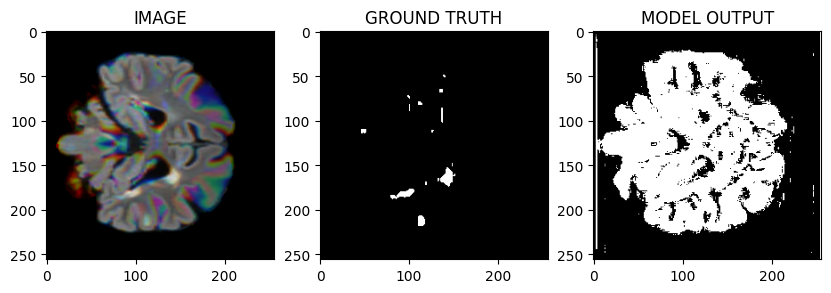

In [30]:
#idx = 689
idx = 592
model.load_state_dict(torch. load('bestModel.pt'))
image, mask = testset[idx]
image1 = image.to(DEVICE)
mask1 = mask.to(DEVICE)
logits_mask = model (image1.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
pred_mask = logits_mask
pred_mask = (pred_mask > 0.5)*1.0
J = 1-BinaryJaccardLoss()(pred_mask, mask1)
I = BinaryIntersection()(pred_mask, mask1)
U = BinaryUnion()(pred_mask, mask1)
S = BinarySum()(pred_mask, mask1)
print(f'Jaccard = {J} ,  Intersection = {I} , Union = {U} , Sum = {S} , Dice = {2*I/S}')


helper.show_image(image, mask, pred_mask.detach().cpu().squeeze(0))

Jaccard = 2.8848648071289062e-05 ,  Intersection = 0.0 , Union = 34693.0 , Sum = 34693.0 , Dice = 0.0


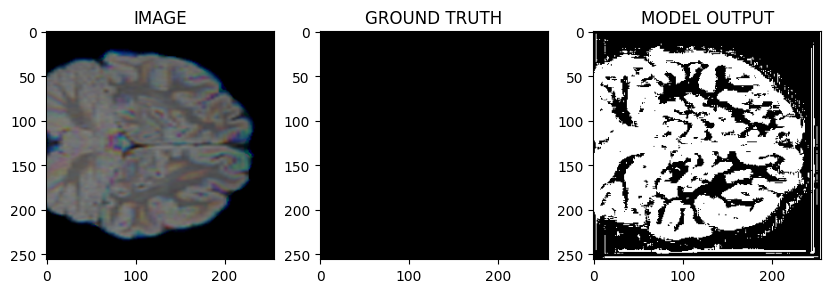

In [31]:
idx = 40
#model.load_state_dict(torch. load('bestModel.pt'))
image, mask = testset[idx]
image1 = image.to(DEVICE)
mask1 = mask.to(DEVICE)
logits_mask = model (image1.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
pred_mask = logits_mask
pred_mask = (pred_mask > 0.5)*1.0
J = 1-BinaryJaccardLoss()(pred_mask, mask1)
I = BinaryIntersection()(pred_mask, mask1)
U = BinaryUnion()(pred_mask, mask1)
S = BinarySum()(pred_mask, mask1)
print(f'Jaccard = {J} ,  Intersection = {I} , Union = {U} , Sum = {S} , Dice = {2*I/S}')


helper.show_image(image, mask, pred_mask.detach().cpu().squeeze(0))

In [32]:
J = [0]*len(validset)
I = [0]*len(validset)
U = [0]*len(validset)
S = [0]*len(validset)
for idx in range(len(validset)):
    image, mask = validset[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)
    S[idx] = BinarySum()(pred_mask, mask)

print(f'Jaccard = {sum(I)/sum(U)*100} , Dice = {2*sum(I)/sum(S)*100} ,  Intersection = {sum(I)} , Union = {sum(U)} , Sum = {sum(S)}')

J_valid = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of validation set = ', torch.mean(J_valid)*100)


Jaccard = 0.6219218373298645 , Dice = 1.2361565828323364 ,  Intersection = 320337.0 , Union = 51507596.0 , Sum = 51827900.0
Jaccard Avg of validation set =  tensor(0.5787)


In [33]:
J = [0]*len(testset)
I = [0]*len(testset)
U = [0]*len(testset)
S = [0]*len(testset)
sx, su = 0, 0
for idx in range(len(testset)):
    image, mask = testset[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)
    S[idx] = BinarySum()(pred_mask, mask)

print(f'Jaccard = {sum(I)/sum(U)*100} , Dice = {2*sum(I)/sum(S)*100} ,  Intersection = {sum(I)} , Union = {sum(U)} , Sum = {sum(S)}')

J_test = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of test set = ', torch.mean(J_test)*100)


Jaccard = 0.6122788786888123 , Dice = 1.217104434967041 ,  Intersection = 330599.0 , Union = 53994840.0 , Sum = 54325496.0
Jaccard Avg of test set =  tensor(0.5893)


In [34]:
J = [0]*len(testset0)
I = [0]*len(testset0)
U = [0]*len(testset0)
sx, su = 0, 0
for idx in range(len(testset0)):
    image, mask = testset0[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)

print(f'Jaccard = , {sum(I)/sum(U)*100} ,  Intersection = {sum(I)} , Union = {sum(U)}')

J_test = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of test set = ', torch.mean(J_test)*100)


Jaccard = , 0.8195077776908875 ,  Intersection = 330637.0 , Union = 40345804.0
Jaccard Avg of test set =  tensor(0.8389)


In [35]:
J = [0]*len(testset100)
I = [0]*len(testset100)
U = [0]*len(testset100)
sx, su = 0, 0
for idx in range(len(testset100)):
    image, mask = testset100[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)

print(f'Jaccard = , {sum(I)/sum(U)*100} ,  Intersection = {sum(I)} , Union = {sum(U)}')

J_test = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of test set = ', torch.mean(J_test)*100)



Jaccard = , 1.792749047279358 ,  Intersection = 249679.0 , Union = 13927158.0
Jaccard Avg of test set =  tensor(1.8357)
